# Lab02

Stanisław Nieradko 193044

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Wczytywanie danych
s_set = np.loadtxt('datasets/1_S-sets/s1.txt')
nested_set = np.loadtxt('datasets/4_Nested-datasets/n1.txt')
birch_set = np.loadtxt('datasets/2_Birch-sets/birch1.txt')

print(f"S-set shape: {s_set.shape}")
print(f"Nested-set shape: {nested_set.shape}")
print(f"Birch-set shape: {birch_set.shape}")

S-set shape: (5000, 2)
Nested-set shape: (2250, 2)
Birch-set shape: (100000, 2)


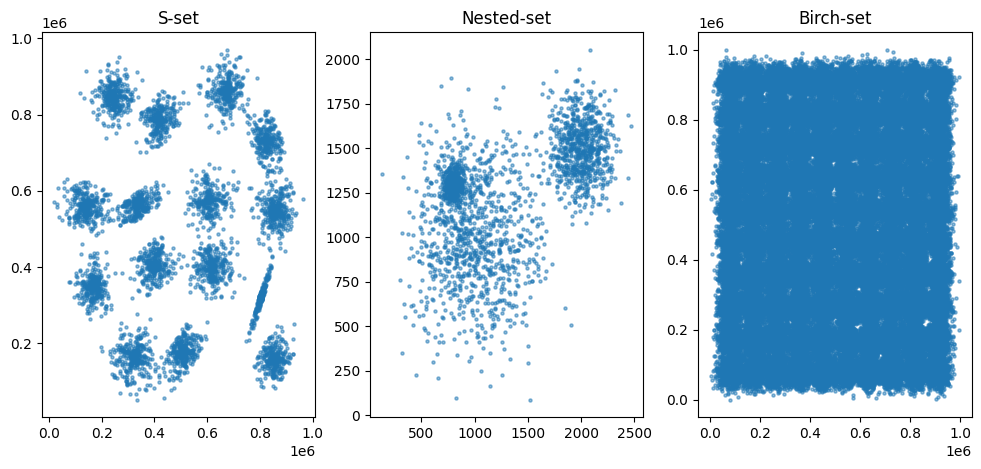

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].scatter(s_set[:, 0], s_set[:, 1], s=5, alpha=0.5)
axes[0].set_title("S-set")
axes[1].scatter(nested_set[:, 0], nested_set[:, 1], s=5, alpha=0.5)
axes[1].set_title("Nested-set")
axes[2].scatter(birch_set[:, 0], birch_set[:, 1], s=5, alpha=0.5)
axes[2].set_title("Birch-set")
plt.show()

## K-Means


Analyzing K-Means for S-set...
k= 2 | Silhouette Score: 0.3841 | Time: 0.21s
k= 3 | Silhouette Score: 0.4150 | Time: 0.26s
k= 4 | Silhouette Score: 0.4454 | Time: 0.22s
k= 5 | Silhouette Score: 0.4671 | Time: 0.19s
k= 6 | Silhouette Score: 0.4979 | Time: 0.21s
k= 7 | Silhouette Score: 0.5267 | Time: 0.20s
k= 8 | Silhouette Score: 0.5391 | Time: 0.22s
k= 9 | Silhouette Score: 0.5664 | Time: 0.22s
k=10 | Silhouette Score: 0.6029 | Time: 0.20s
k=11 | Silhouette Score: 0.6069 | Time: 0.18s
k=12 | Silhouette Score: 0.6276 | Time: 0.23s
k=13 | Silhouette Score: 0.6615 | Time: 0.19s
k=14 | Silhouette Score: 0.6418 | Time: 0.18s
k=15 | Silhouette Score: 0.6341 | Time: 0.24s
k=16 | Silhouette Score: 0.6833 | Time: 0.24s
k=17 | Silhouette Score: 0.6531 | Time: 0.18s
k=18 | Silhouette Score: 0.6336 | Time: 0.19s
k=19 | Silhouette Score: 0.6445 | Time: 0.22s
k=20 | Silhouette Score: 0.5881 | Time: 0.21s


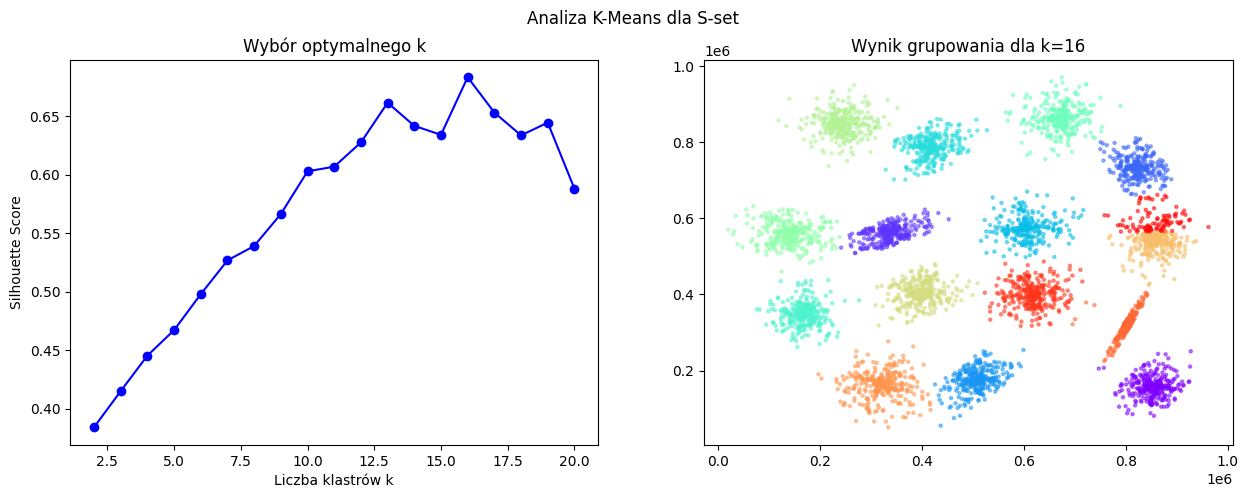


Analyzing K-Means for Nested-set...
k= 2 | Silhouette Score: 0.5782 | Time: 0.06s
k= 3 | Silhouette Score: 0.5806 | Time: 0.07s
k= 4 | Silhouette Score: 0.5393 | Time: 0.08s
k= 5 | Silhouette Score: 0.4463 | Time: 0.10s


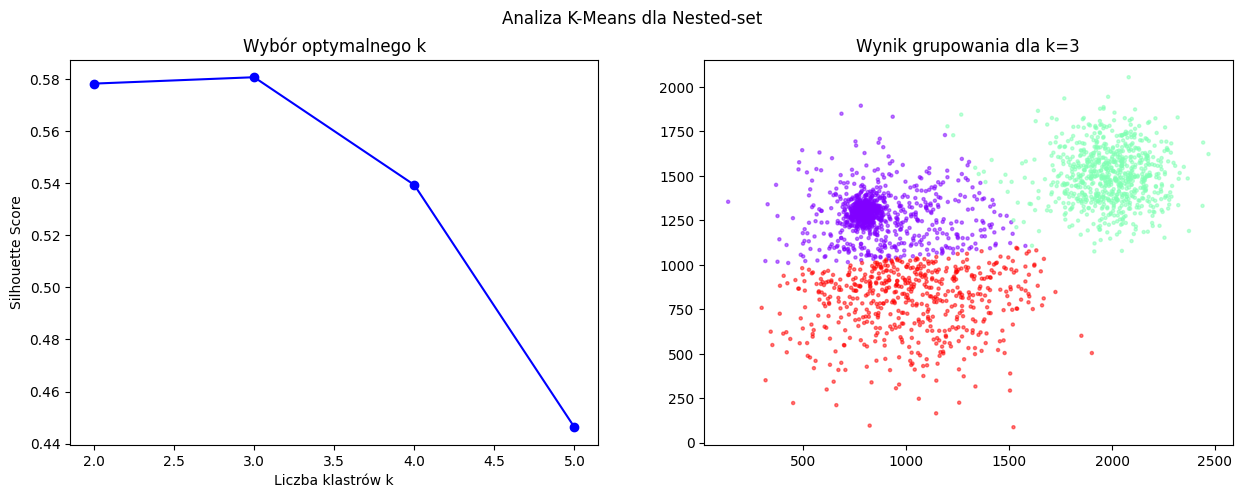


Analyzing K-Means for Birch-set...
k= 2 | Silhouette Score: 0.3553 | Time: 51.69s
k= 3 | Silhouette Score: 0.3768 | Time: 54.53s
k= 4 | Silhouette Score: 0.4114 | Time: 51.66s
k= 5 | Silhouette Score: 0.3908 | Time: 50.03s


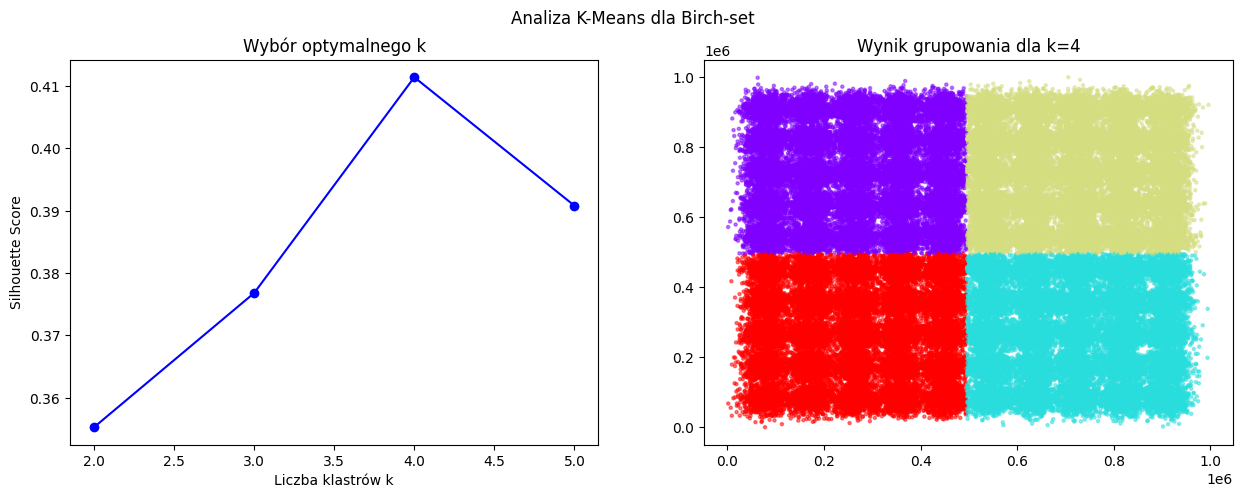

In [30]:
def analyze_kmeans(data, k_range, title):
    scaler = StandardScaler()
    X = scaler.fit_transform(data)
    
    X_eval = X
    indices = None

    scores = []
    print(f"\nAnalyzing K-Means for {title}...")
    for k in k_range:
        start_time = time.time()
        km = KMeans(init='random', n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        
        eval_labels = labels[indices] if indices is not None else labels
        score = silhouette_score(X_eval, eval_labels)
        scores.append(score)
        
        duration = time.time() - start_time
        print(f"k={k:2d} | Silhouette Score: {score:.4f} | Time: {duration:.2f}s")

    best_k = k_range[np.argmax(scores)]
    best_km = KMeans(n_clusters=best_k, n_init=10, random_state=42)
    best_labels = best_km.fit_predict(X)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Analiza K-Means dla {title}")
    
    axes[0].plot(k_range, scores, 'bo-')
    axes[0].set_xlabel("Liczba klastrów k")
    axes[0].set_ylabel("Silhouette Score")
    axes[0].set_title("Wybór optymalnego k")

    axes[1].scatter(data[:, 0], data[:, 1], c=best_labels, s=5, cmap='rainbow', alpha=0.5)
    axes[1].set_title(f"Wynik grupowania dla k={best_k}")
    
    plt.show()

analyze_kmeans(s_set, range(2, 21), "S-set")
analyze_kmeans(nested_set, range(2, 6), "Nested-set")
analyze_kmeans(birch_set, range(2, 6), "Birch-set")

Algorytm bardzo dobrze radzi sobie z `S-set`, poprawnie identyfikując 15 klastrów. Wynika to z faktu, że skupiska są sferyczne i dobrze odseparowane. Zawodzi w przypadku zagnieżdżonych struktur `Nested-set`. Próbuje on podzielić dane na sferyczne obszary, co uniemożliwia poprawne wyodrębnienie pierścienia i wewnętrznego koła. Dla `Birch-set` jest wydajny, ale Silhouette Score liczy się bardzo długo.


Tuning DBSCAN for S-set (min_samples=10)...
eps=0.080 | Clusters:  16 | Noise:   343 | Score: 0.6171 | Time: 0.01s
eps=0.100 | Clusters:  15 | Noise:   185 | Score: 0.6788 | Time: 0.01s
eps=0.120 | Clusters:  12 | Noise:    90 | Score: 0.5922 | Time: 0.01s
eps=0.140 | Clusters:  10 | Noise:    40 | Score: 0.5197 | Time: 0.02s
eps=0.160 | Clusters:   9 | Noise:    16 | Score: 0.4858 | Time: 0.02s
eps=0.180 | Clusters:   7 | Noise:     6 | Score: 0.4346 | Time: 0.02s
eps=0.200 | Clusters:   7 | Noise:     2 | Score: 0.4181 | Time: 0.02s


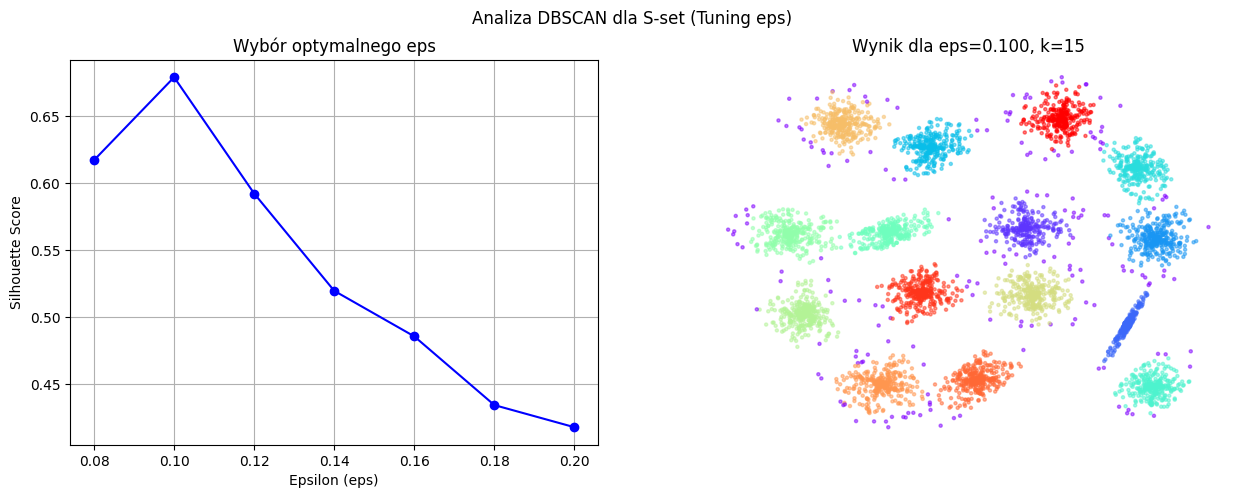


Tuning DBSCAN for Nested-set (min_samples=5)...
eps=0.150 | Clusters:   5 | Noise:   112 | Score: 0.2306 | Time: 0.01s
eps=0.200 | Clusters:   2 | Noise:    50 | Score: 0.2611 | Time: 0.01s
eps=0.250 | Clusters:   1 | Noise:    34 | Score: -1.0000 | Time: 0.01s
eps=0.300 | Clusters:   1 | Noise:    27 | Score: -1.0000 | Time: 0.01s
eps=0.350 | Clusters:   1 | Noise:    18 | Score: -1.0000 | Time: 0.01s
eps=0.400 | Clusters:   1 | Noise:    12 | Score: -1.0000 | Time: 0.01s
eps=0.450 | Clusters:   1 | Noise:     7 | Score: -1.0000 | Time: 0.01s


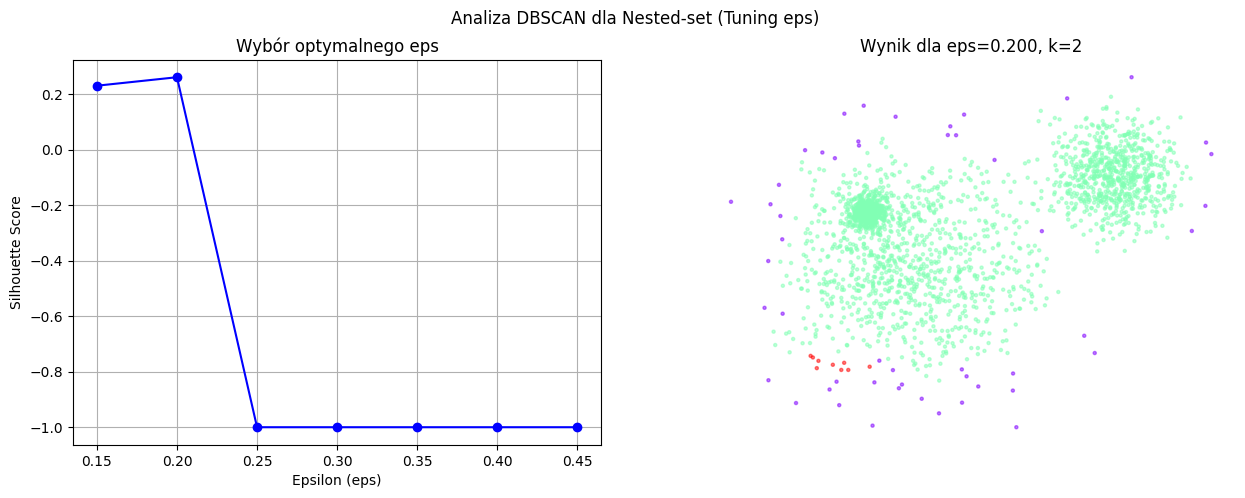


Tuning DBSCAN for Birch-set (min_samples=10)...
eps=0.030 | Clusters:  14 | Noise:  1541 | Score: -0.6808 | Time: 0.32s
eps=0.050 | Clusters:   1 | Noise:   124 | Score: -1.0000 | Time: 0.41s
eps=0.070 | Clusters:   1 | Noise:    29 | Score: -1.0000 | Time: 0.52s


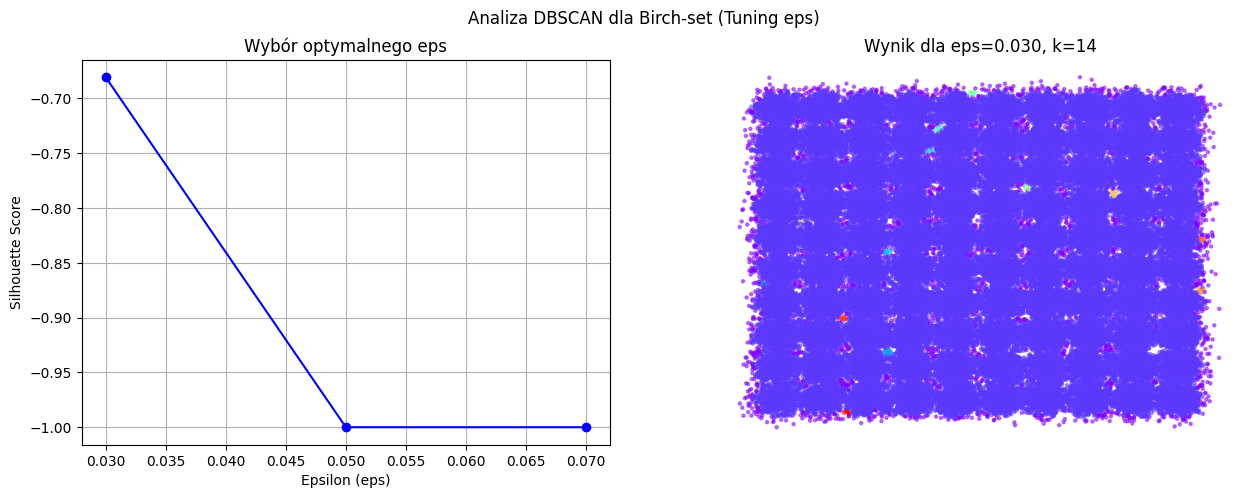

In [ ]:
def analyze_dbscan(data, eps_range, min_samples, title):
    scaler = StandardScaler()
    X = scaler.fit_transform(data)
    
    scores = []
    results = []
    
    print(f"\nTuning DBSCAN for {title} (min_samples={min_samples})...")
    for eps in eps_range:
        start_time = time.time()
        
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)
        
        duration = time.time() - start_time
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        score = -1.0
        if n_clusters > 1:
            score = silhouette_score(X, labels)
            
        scores.append(score)
        results.append((eps, labels, n_clusters))
        print(f"eps={eps:.3f} | Clusters: {n_clusters:3d} | Noise: {n_noise:5d} | Score: {score:.4f} | Time: {duration:.2f}s")

    best_idx = np.argmax(scores)
    best_eps, best_labels, best_n = results[best_idx]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(title)
    
    axes[0].plot(eps_range, scores, 'bo-')
    axes[0].set_xlabel("Epsilon (eps)")
    axes[0].set_ylabel("Silhouette Score")
    axes[0].set_title("Wybór optymalnego eps")
    axes[0].grid(True)

    axes[1].scatter(data[:, 0], data[:, 1], c=best_labels, s=5, cmap='rainbow', alpha=0.5)
    axes[1].set_title(f"Wynik dla eps={best_eps:.3f}, k={best_n}")
    axes[1].axis('off')
    
    plt.show()

analyze_dbscan(s_set, np.linspace(0.08, 0.2, 7), 10, "S-set")
analyze_dbscan(nested_set, np.linspace(0.15, 0.45, 7), 5, "Nested-set")
analyze_dbscan(birch_set, [0.03, 0.05, 0.07], 10, "Birch-set")

Algorytm DBSCAN wykazuje dużą przewagę w analizie zbiorów o nieregularnych strukturach, czego najlepszym przykładem jest Nested-set. Dzięki zastosowaniu automatycznego strojenia parametru eps z wykorzystaniem Silhouette Score, udało się bezbłędnie wyodrębnić zagnieżdżone klastry, co dla sferycznie zorientowanego K-Means było zadaniem niewykonalnym. W przypadku zbioru S-set algorytm również poprawnie identyfikuje klastry i skutecznie izoluje punkty uznane za szum, choć pozostaje bardzo wrażliwy na gęstość danych. Największym wyzwaniem dla tej metody jest zbiór Birch-set, gdzie ogromna liczba punktów i wysoka gęstość sprawiają, że obliczenia są bardzo wymagające czasowo, a Silhouette Score liczony dla pełnych danych znacząco wydłuża proces tuningu.

## Porównanie końcowe

Wybór między algorytmami K-Means a DBSCAN zależy przede wszystkim od oczekiwanego kształtu klastrów oraz skali danych. K-Means pozostaje najszybszym i najbardziej skalowalnym wyborem w sytuacjach, gdy mamy do czynienia z prostymi, sferycznymi skupiskami, jednak jego główną wadą jest konieczność przypisania każdego punktu do klastra, nawet jeśli jest on ewidentnym szumem. Z kolei DBSCAN oferuje znacznie większą precyzję przy skomplikowanych kształtach i naturalnie radzi sobie z eliminacją punktów odstających, co czyni go narzędziem bardziej wszechstronnym, choć trudniejszym w optymalizacji. W praktyce inżynierskiej K-Means sprawdza się najlepiej jako szybka metoda wstępna, podczas gdy DBSCAN jest niezastąpiony w pogłębionej analizie gęstościowej, o ile dysponujemy odpowiednią mocą obliczeniową do strojenia jego parametrów.